In [31]:
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
import json
from itertools import combinations
from scipy.stats import ttest_ind
import pandas as pd
plt.style.use('default')

Entire the desired output_directory, model_name, and metric we care about. Then run all the code below

In [24]:
output_dir = 'sizes'

output_dir = Path('/data/vision/polina/users/marcusbl/bin_class/outputs') / output_dir

model_name = 'model_loss'
metrics = ['auc', 'tpr_at_10%', 'tpr_at_20%', 'tpr_at_30%']
# metrics = ['auc']

Parse results into Pandas DF

In [25]:
results = []

for test_dir in output_dir.iterdir():
    if not test_dir.is_dir():
        continue
    for run_dir in test_dir.iterdir():
        if not run_dir.is_dir():
            continue
        
        with open(run_dir / 'test_info' / 'metric_info.json') as f:
            metric_info = json.load(f)

        flat = {
            (model, metric): value
            for model, metrics in metric_info.items()
            for metric, value in metrics.items()
        }

        results.append({
            "test": test_dir.name,
            "run": run_dir.name,
            **flat
        })

df = pd.DataFrame(results).set_index(["test", "run"])

df.columns = pd.MultiIndex.from_tuples(df.columns)
df = df.sort_index(axis=1).sort_index()


In [26]:
df['model_auc']

acc    auc  epoch     f1   fn   fp    fpr   loss   prec  recall  \
test run                                                                       
25   run0  0.840  0.850     -1  0.513  121   44  0.054  0.428  0.664   0.418   
     run1  0.848  0.855     -1  0.606   67   89  0.106  0.395  0.574   0.642   
     run2  0.878  0.882     -1  0.620   67   46  0.060  0.396  0.667   0.579   
     run3  0.764  0.837     -1  0.422   27  222  0.237  0.666  0.291   0.771   
     run4  0.910  0.854     -1  0.549   74   23  0.024  0.273  0.720   0.444   
     run5  0.877  0.895     -1  0.686   68   70  0.078  0.347  0.683   0.689   
     run6  0.902  0.908     -1  0.721   41   76  0.076  0.331  0.665   0.786   
     run7  0.849  0.850     -1  0.502  118   43  0.050  0.425  0.653   0.407   
     run8  0.867  0.807     -1  0.473   87   67  0.067  0.377  0.507   0.442   
     run9  0.935  0.955     -1  0.808   38   30  0.035  0.181  0.827   0.790   
35   run0  0.858  0.867     -1  0.616   91   55  0.067  0.461  0.680   0.562   
     run1  0.821  0.858     -1  0.605   47  136  0.163  0.437  0.507   0.749   
     run2  0.880  0.938     -1  0.699   30   81  0.106  0.256  0.614   0.811   
     run3  0.813  0.904     -1  0.491   23  174  0.186  0.389  0.353   0.805   
     run4  0.924  0.926     -1  0.692   41   41  0.043  0.221  0.692   0.692   
     run5  0.896  0.940     -1  0.737   55   62  0.069  0.240  0.726   0.749   
     run6  0.915  0.934     -1  0.739   49   52  0.052  0.227  0.733   0.745   
     run7  0.889  0.886     -1  0.672   78   40  0.046  0.437  0.752   0.608   
     run8  0.909  0.915     -1  0.549   92   13  0.013  0.245  0.831   0.410   
     run9  0.538  0.942     -1  0.426    2  481  0.556  0.982  0.271   0.989   
50   run0  0.850  0.877     -1  0.658   60   94  0.114  0.380  0.612   0.712   
     run1  0.905  0.894     -1  0.698   75   22  0.026  0.315  0.836   0.599   
     run2  0.742  0.902     -1  0.548   14  225  0.293  0.729  0.392   0.912   
     run3  0.861  0.927     -1  0.568   22  124  0.133  0.310  0.436   0.814   
     run4  0.910  0.952     -1  0.707   16   81  0.085  0.248  0.591   0.880   
     run5  0.889  0.937     -1  0.738   43   82  0.091  0.275  0.682   0.804   
     run6  0.929  0.955     -1  0.745   68   17  0.017  0.190  0.879   0.646   
     run7  0.838  0.912     -1  0.655   36  136  0.157  0.395  0.545   0.819   
     run8  0.901  0.906     -1  0.482  103   11  0.011  0.334  0.828   0.340   
     run9  0.931  0.970     -1  0.818   19   53  0.061  0.181  0.753   0.895   

            tn   tp    tpr  tpr_at_10%  tpr_at_20%  tpr_at_30%  
test run                                                        
25   run0  777   87  0.418       0.692       0.745       0.827  
     run1  747  120  0.642       0.636       0.754       0.834  
     run2  721   92  0.579       0.616       0.736       0.843  
     run3  713   91  0.771       0.568       0.729       0.805  
     run4  925   59  0.444       0.602       0.714       0.842  
     run5  833  151  0.689       0.735       0.836       0.881  
     run6  923  151  0.786       0.807       0.880       0.891  
     run7  823   81  0.407       0.553       0.754       0.839  
     run8  934   69  0.442       0.558       0.647       0.744  
     run9  835  143  0.790       0.884       0.950       0.961  
35   run0  766  117  0.562       0.601       0.745       0.837  
     run1  700  140  0.749       0.690       0.786       0.818  
     run2  686  129  0.811       0.786       0.906       0.956  
     run3  761   95  0.805       0.678       0.814       0.924  
     run4  907   92  0.692       0.827       0.917       0.932  
     run5  841  164  0.749       0.817       0.895       0.954  
     run6  947  143  0.745       0.833       0.885       0.927  
     run7  826  121  0.608       0.704       0.794       0.854  
     run8  988   64  0.410       0.795       0.859       0.897  
     run9  384  179  0.989       0.823       0.939       0.956  
50   run0  727  148  0

Average/Variance for desired metrics over all runs for the desired model

In [27]:
m = df[model_name]

stats = m.groupby(level='test').agg(['mean', 'var'])

stats = stats.sort_values(by=('auc', 'mean'), ascending=False)

stats[[(metric, stat) for metric in metrics for stat in ['mean', 'var']]]

auc           tpr_at_10%           tpr_at_20%           tpr_at_30%  \
        mean       var       mean       var       mean       var       mean   
test                                                                          
50    0.9147  0.001051     0.7793  0.006965     0.8649  0.004453     0.9073   
35    0.9082  0.001405     0.7568  0.006525     0.8484  0.004952     0.8962   
25    0.8570  0.001560     0.6417  0.009539     0.7605  0.006407     0.8330   

                
           var  
test            
50    0.002295  
35    0.003592  
25    0.003210

Paired T-test for signficance. Note that it's paired b/c same seed for each 

In [28]:
from scipy.stats import ttest_rel
import pandas as pd
import numpy as np

rows = []

tests = m.index.get_level_values("test").unique()

for metric in metrics:
    # Pull each test's series once
    series_by_test = {}
    for test in tests:
        s = m.loc[test, metric]
        if isinstance(s, pd.DataFrame):
            raise ValueError(f"Expected a Series for test={test}, metric={metric}, got DataFrame.")
        series_by_test[test] = s.dropna()

    # Mean over available runs for ranking
    mean_per_test = pd.Series({
        test: s.mean() for test, s in series_by_test.items() if len(s) > 0
    })

    if mean_per_test.empty:
        continue

    # Best test for this metric
    best_test = mean_per_test.idxmax()
    best_vals = series_by_test[best_test]

    for test in tests:
        if test == best_test:
            continue

        other_vals = series_by_test[test]

        # Align by run/seed so only matching runs are compared
        paired = pd.concat(
            [best_vals.rename("best"), other_vals.rename("other")],
            axis=1,
            join="inner"
        ).dropna()

        n_pairs = len(paired)

        if n_pairs < 2:
            mean_best = np.nan
            mean_test = np.nan
            diff = np.nan
            t_stat = np.nan
            p_value = np.nan
        else:
            mean_best = paired["best"].mean()
            mean_test = paired["other"].mean()
            diff = (paired["best"] - paired["other"]).mean()
            t_stat, p_value = ttest_rel(paired["best"], paired["other"], nan_policy="omit")

        rows.append({
            "metric": metric,
            "best_test": best_test,
            "test": test,
            "mean_best": mean_best,
            "mean_test": mean_test,
            "diff": diff,
            "n_pairs": n_pairs,
            "t_stat": t_stat,
            "p_value": p_value,
            "significant": bool(p_value < 0.05) if pd.notna(p_value) else np.nan,
        })

paired_tstats = (
    pd.DataFrame(rows)
    .set_index(["metric", "best_test", "test"])
    .sort_index()
)

paired_tstats

mean_best  mean_test    diff  n_pairs    t_stat  \
metric     best_test test                                                    
auc        50        25       0.9147     0.8570  0.0577       10  6.098663   
                     35       0.9147     0.9082  0.0065       10  0.740610   
tpr_at_10% 50        25       0.7793     0.6417  0.1376       10  5.050759   
                     35       0.7793     0.7568  0.0225       10  1.130057   
tpr_at_20% 50        25       0.8649     0.7605  0.1044       10  4.327255   
                     35       0.8649     0.8484  0.0165       10  1.131019   
tpr_at_30% 50        25       0.9073     0.8330  0.0743       10  4.410266   
                     35       0.9073     0.8962  0.0111       10  0.995610   

                            p_value  significant  
metric     best_test test                         
auc        50        25    0.000180         True  
                     35    0.477806        False  
tpr_at_10% 50        25    0.000690         True  
                     35    0.287668        False  
tpr_at_20% 50        25    0.001913         True  
                     35    0.287284        False  
tpr_at_30% 50        25    0.001695         True  
                     35    0.345452        False

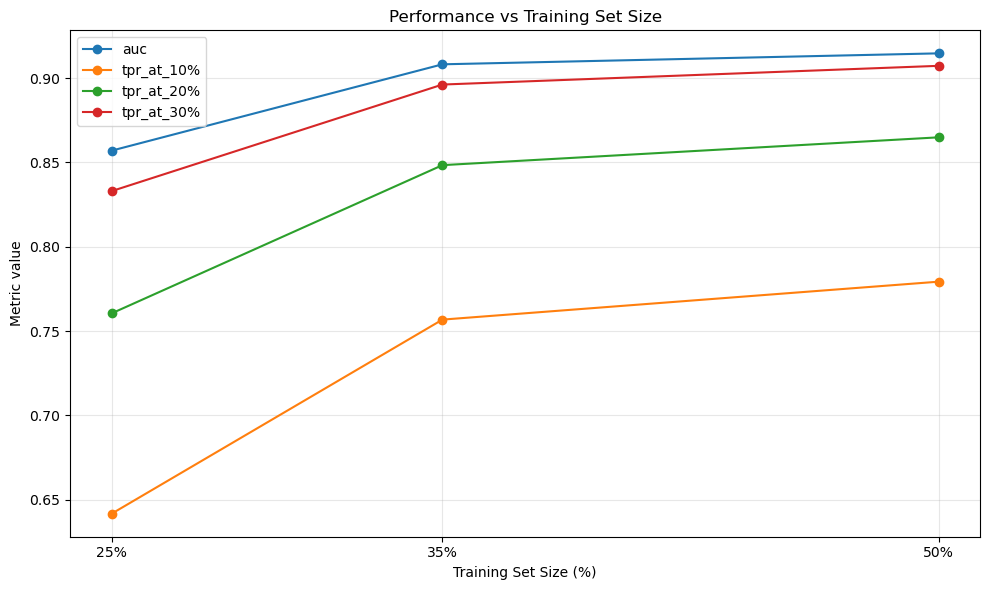

In [34]:
m = df[model_name]

stats = m.groupby(level="test").agg(["mean", "var"])
stats = stats.sort_index()  # sort by test size for plotting

plt.figure(figsize=(10, 6))

for metric in metrics:
    y = stats[(metric, "mean")]
    x = y.index.astype(float)

    plt.plot(
        x,
        y.values,
        marker="o",
        label=metric
    )

xticks = stats.index.astype(float)
plt.xticks(xticks, [f"{int(x)}%" for x in xticks])

plt.xlabel("Training Set Size (%)")
plt.ylabel("Metric value")
plt.title("Performance vs Training Set Size")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()